# Fitting the unified sleep model to irregular observations

This tutorial demonstrates how to recover the parameters of a sleep-homeostasis model from a **scalar signal** (e.g. a PVT-like performance measure) sampled at irregular times.

We use the `"Chronic Sleep Restriction: 21h / 3h → Recovery: 16h / 8h"` diary as the ground-truth schedule — 5 days of CSR followed by 3 recovery days, 192 h in total.

The forward pass (`Model.compute`) is implemented with PyTorch, so gradients flow from the observation loss back to the physiological time constants (`t_w`, `t_s`, `t_la`), which we fit with Adam.


In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0,"C:/Users/robin/Documents/Postdoc_Stanford/UMP_computation/sleep/src/")  # ou le chemin absolu vers ton dossier

from sleep import Model

%load_ext autoreload
%autoreload 2

In [2]:
diary = pd.read_csv("data/diary.csv")
diary.head()

,key,asleep,awake,rested
0,Adaptation → Sleep Deprivation: 64h → Recovery...,NaN,0.0,False
1,Adaptation → Sleep Deprivation: 64h → Recovery...,16.0,24.0,False
2,Adaptation → Sleep Deprivation: 64h → Recovery...,40.0,48.0,True
3,Adaptation → Sleep Deprivation: 64h → Recovery...,112.0,120.0,False
4,Adaptation → Sleep Deprivation: 64h → Recovery...,136.0,144.0,False


## Forward evaluation

Instantiate the model and visualise homeostasis and debt trajectories for all three diaries at the default parameters.


In [3]:
model = Model("unified_for_PVT", diary)
print(model)

Total of 3 diaries provided.
----------------------------------------
Unified sleep model for PVT estimation computing:
- Homeostasis (s): sleep pressure
- Debt (d): sleep debt

- PVT: psychomotor vigilance test predicted

During wake:
  ds/dt = (1 - s) / t_w
  dd/dt = (-d + 1) / t_la

During sleep:
  ds/dt = -(s - d) / t_s
  dd/dt = (-d - wsr) / t_la

Circadian time is calculated using the hour of the day t and a phase Phi:
C= 0.97*sin(2*pi*(t+Phi)/24) + 0.22*sin(2*2*pi*(t+Phi)/24)+0.07*sin(3*2*pi*(t+Phi)/24)+0.03*sin(4*2*pi*(t+Phi)/24)+0.001*sin(5*2*pi*(t+Phi)/24)


{'homeostasis': [None, None, None], 'debt': [None, None, None], 'PVT': [None, None, None], 'circadian': [None, None, None]}


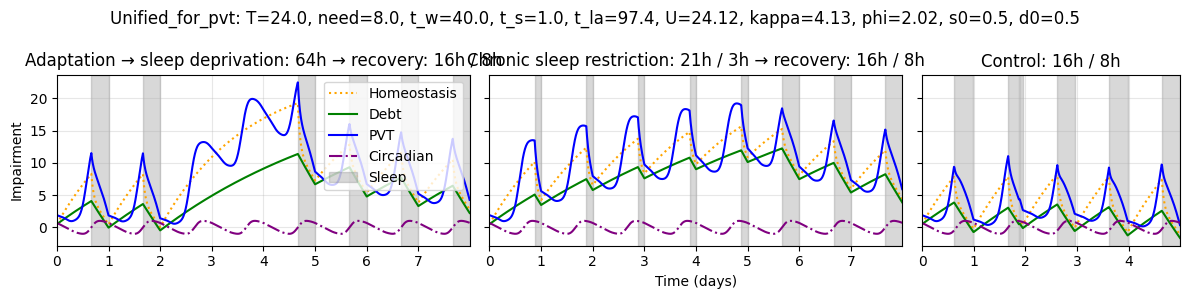

In [4]:
#WARNING le paramètre U est mal géré: on n'est pas conforme au UMP original
fig, axs = model.plot(key=list(model.key_id.keys()))
#fig.savefig("/figures/example.png", dpi=300, bbox_inches="tight")

## Fitting to irregular scalar observations

We now treat this as an inverse problem. Given noisy measurements `y_i = s(t_i) + ε_i` of the homeostasis signal at irregular times, can we recover the time constants `t_w, t_s, t_la`?

- **Schedule:** Chronic Sleep Restriction → Recovery (192 h).
- **Sampling:** 4–6 observations per day, drawn uniformly within each 24 h window.
- **Ground truth:** package defaults (`t_w=40`, `t_s=1`, `t_la=97.4`), with `T=24`, `need=8` held fixed.
- **Noise:** Gaussian, σ = 0.03.
- **Optimizer:** Adam on _log-parameterized_ time constants. This guarantees positivity under unconstrained gradient descent; the ordering constraints `t_s, t_w < t_la` are satisfied at the optimum and checked post-hoc.


In [5]:
key = "Chronic Sleep Restriction: 21h / 3h → Recovery: 16h / 8h"

ts = torch.tensor([0.0, 1.0, 2.0])
ts2 = ts+1
ex1 = model.compute(key=key, time=ts)["PVT"]
ex2 = model.compute(key=key, time=ts2)["PVT"]
print((ts, ts2))
print(ex1)
print(ex2)
#c'est différent parce que dans un cas on applique l'initialisation s0=0 et d0=0 à t=0 et dans l'autre on l'applique à t=1.

{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
(tensor([0., 1., 2.]), tensor([1., 2., 3.]))
tensor([1.8854, 1.7529, 1.6384])
tensor([1.7529, 1.6384, 1.5091])


In [6]:
#grosse leçon, si t_start et obs_times ne commencent pas tous les 2 par 0, il y a qq chose
#  qui plante à cause de la phase circadienne. Comprendre pouquoi.
key = "Chronic Sleep Restriction: 21h / 3h → Recovery: 16h / 8h"
diary_key = diary.loc[diary.key == key]
t_start = float(diary_key.awake.min())
t_end = float(diary_key.awake.max())
n_days = int((t_end - t_start) / 24)

# Draw 4–6 irregular observation times per 24 h window.
rng = np.random.default_rng(42)

obs_times_plus = np.concatenate(
    [
        np.sort(rng.uniform(t_start + d * 24, t_start + (d + 1) * 24, rng.integers(10, 15)))
        for d in range(n_days)
    ]
)
print(obs_times_plus)
obs_times = np.concatenate([np.array([t_start]), obs_times_plus])

# Ground-truth signal = homeostasis at default params (as numpy).
y_true = model.compute(key=key, time=obs_times)["PVT"]

# Observation = signal + Gaussian noise.
noise_std = 0.5
y_obs = y_true + rng.normal(0.0, noise_std, size=obs_times.shape)

#on retire le premier point d'observation à t=0 qui a été rajouté artificiellement pour éviter les problèmes de phase circadienne
y_true = y_true[1:]
obs_times = obs_times[1:]
y_obs = y_obs[1:]


print(
    f"{len(obs_times)} observations across {n_days} days (avg {len(obs_times) / n_days:.1f} / day)"
)

[  2.26025635   3.07472718   8.89915258  10.53308255  10.80926251
  16.7368327   18.26735285  18.86554333  20.60635008  23.41493644
  25.53161415  29.45372932  32.50862324  34.64194077  37.31003489
  39.15994558  39.45276288  42.19410576  43.74627872  43.86314813
  45.43490691  46.24235973  47.29675259  49.05129038  51.11811613
  51.70294781  52.54731262  52.67132899  55.8198086   56.89103294
  59.20130409  59.26933947  59.41691823  64.39317488  65.87429174
  71.22023358  75.35405961  76.79779686  77.44582438  78.91987449
  79.49679939  81.2994811   82.49164605  88.07553587  88.3798921
  88.80636245  91.31434458  91.97423523  91.98427671  98.74872176
  99.35512796 107.01397861 107.30630895 109.28590562 109.56566656
 109.6497887  111.23323968 111.95642056 112.04167108 112.92396909
 114.35997258 114.73749674 114.88618506 120.73962803 121.3992658
 125.15003215 125.61454766 126.75321341 127.29480235 129.80468745
 130.48121734 133.42097186 140.48167376 144.54508976 146.16114866
 147.6554904

[0.00000000e+00 9.60480240e-02 1.92096048e-01 ... 1.91807904e+02
 1.91903952e+02 1.92000000e+02]
{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
[1.8854345 1.8720177 1.8586563 ... 5.95078   5.8284683 5.7062964]


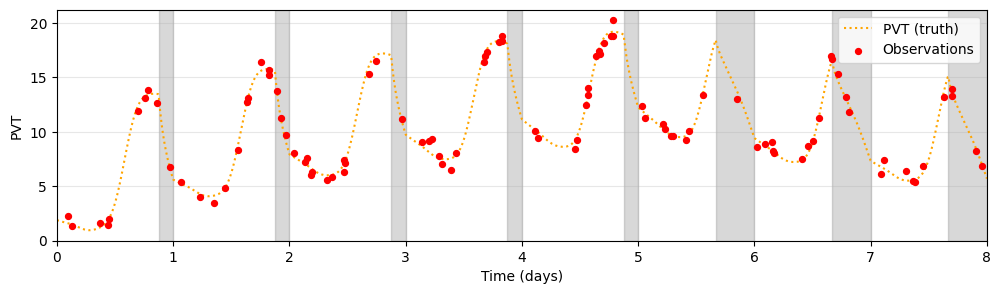

In [7]:
# Sanity check: overlay observations on the continuous ground-truth trajectory.
t_dense = np.linspace(t_start, t_end, 2000)
print(t_dense)
s_dense_truth = model.compute(key=key, time=t_dense)["PVT"]
print(s_dense_truth)


fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(
    (t_dense - t_start) / 24,
    s_dense_truth,
    color="orange",
    linestyle="dotted",
    lw=1.5,
    label="PVT (truth)",
)
for asleep, awake in zip(diary_key["asleep"], diary_key["awake"]):
    if pd.notna(asleep):
        ax.axvspan((asleep - t_start) / 24, (awake - t_start) / 24, color="gray", alpha=0.3)
ax.scatter((obs_times - t_start) / 24, y_obs, color="red", s=18, zorder=3, label="Observations")
ax.set_xlim(0, (t_end - t_start) / 24)
ax.set_xlabel("Time (days)")
ax.set_ylabel("PVT")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.show()

In [8]:
# Log-parameterization keeps time constants positive under unconstrained optimisation.
# Initial values are deliberately perturbed away from the truth.
log_t_w = torch.tensor(float(np.log(30.0)), requires_grad=True)
log_t_s = torch.tensor(float(np.log(0.75)), requires_grad=True)
log_t_la = torch.tensor(float(np.log(70.0)), requires_grad=True)
log_U = torch.tensor(float(np.log(20.5)), requires_grad=True)
log_need = torch.tensor(float(np.log(7.5)), requires_grad=True)
phi = torch.tensor(1.5, requires_grad=True)  # --- IGNORE ---
log_kappa = torch.tensor(float(np.log(0.5)), requires_grad=True)  # --- IGNORE ---
log_s0 = torch.tensor(float(np.log(0.1)), requires_grad=True)  # --- IGNORE ---
log_d0 = torch.tensor(float(np.log(0.1)), requires_grad=True)

obs_t = torch.as_tensor(obs_times, dtype=torch.float32)
y_obs_t = torch.as_tensor(y_obs, dtype=torch.float32)

truth = {"t_w": 40.0, "t_s": 1.0, "t_la": 97.4, "U":24.12, "need": 8.0, "phi": 2.02, "kappa": 4.13, "s0": 0.001, "d0": 0.001}  # --- IGNORE ---
init = {
    "t_w": float(torch.exp(log_t_w)),
    "t_s": float(torch.exp(log_t_s)),
    "t_la": float(torch.exp(log_t_la)),
    "U": float(torch.exp(log_U)),
    "need": float(torch.exp(log_need)),
    "phi": float(phi),
    "kappa": float(torch.exp(log_kappa)),
    "s0": float(torch.exp(log_s0)),
    "d0": float(torch.exp(log_d0))


}
print("Ground truth:", truth)
print("Initial     :", {k: round(v, 3) for k, v in init.items()})

Ground truth: {'t_w': 40.0, 't_s': 1.0, 't_la': 97.4, 'U': 24.12, 'need': 8.0, 'phi': 2.02, 'kappa': 4.13, 's0': 0.001, 'd0': 0.001}
Initial     : {'t_w': 30.0, 't_s': 0.75, 't_la': 70.0, 'U': 20.5, 'need': 7.5, 'phi': 1.5, 'kappa': 0.5, 's0': 0.1, 'd0': 0.1}


C:\Users\robin\AppData\Local\Temp\ipykernel_55712\2861387912.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  "t_w": float(torch.exp(log_t_w)),


In [9]:
optim = torch.optim.Adam([log_t_w, log_t_s, log_t_la, log_U, log_need, phi, log_kappa, log_s0, log_d0], lr=0.05)

n_steps = 300
losses = []
for step in range(n_steps):
    optim.zero_grad()
    params = {"t_w": torch.exp(log_t_w), "t_s": torch.exp(log_t_s), "t_la": torch.exp(log_t_la),
               "U": torch.exp(log_U), "need": torch.exp(log_need), "phi": phi, "kappa": torch.exp(log_kappa),
                 "s0": torch.exp(log_s0), "d0": torch.exp(log_d0)}
    pred = model.compute(key=key, time=obs_t, **params)
    #print(pred)
    loss = ((pred["PVT"] - y_obs_t) ** 2).mean()
    print(loss)
    loss.backward()
    optim.step()
    losses.append(loss.item())
    


fitted = {
    "t_w": float(torch.exp(log_t_w)),
    "t_s": float(torch.exp(log_t_s)),
    "t_la": float(torch.exp(log_t_la)),
    "U": float(torch.exp(log_U)),
    "need": float(torch.exp(log_need)),
    "phi": float(phi),
    "kappa": float(torch.exp(log_kappa)),
    "s0": float(torch.exp(log_s0)),
    "d0": float(torch.exp(log_d0))

}

print(f"Final loss: {losses[-1]:.5f}\n")
print(f"{'Parameter':<6} {'Truth':>10} {'Initial':>10} {'Fitted':>10} {'Rel. err':>10}")
for k in ("t_w", "t_s", "t_la", "U", "need", "phi", "kappa", "s0", "d0"):
    rel = abs(fitted[k] - truth[k]) / truth[k]
    print(f"{k:<6} {truth[k]:>10.3f} {init[k]:>10.3f} {fitted[k]:>10.3f} {rel:>9.1%}")


{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
tensor(9.1066, grad_fn=<MeanBackward0>)
{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
tensor(7.7834, grad_fn=<MeanBackward0>)
{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
tensor(7.8099, grad_fn=<MeanBackward0>)
{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
tensor(7.6669, grad_fn=<MeanBackward0>)
{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
tensor(7.2209, grad_fn=<MeanBackward0>)
{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
tensor(6.9136, grad_fn=<MeanBackward0>)
{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
tensor(6.8561, grad_fn=<MeanBackward0>)
{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}
tensor(6.8443, grad_fn=<MeanBackward0>)
{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [Non

In [10]:
print(pred["homeostasis"].shape)
print(obs_t.shape)  

torch.Size([98])
torch.Size([98])


In [11]:
%matplotlib qt
# Diagnostics: loss curve + fitted vs ground-truth trajectories with observations.
out_fit = model.compute(key=key, time=t_dense, **fitted)
t_days = (t_dense - t_start) / 24

fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1, 3]})

axes[0].semilogy(losses)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE loss")
axes[0].grid(alpha=0.3, which="both")

ax = axes[1]
ax.plot(
    t_days, s_dense_truth, color="orange", linestyle="dotted", lw=1.5, label="PVT (truth)"
)
ax.plot(t_days, out_fit["PVT"], color="red", lw=1.5, label="PVT (fitted)")
ax.plot(t_days, out_fit["homeostasis"], color="C0", lw=1.5, label="Homeostasis (fitted)")
ax.plot(t_days, out_fit["debt"], color="green", lw=1.0, alpha=0.8, label="Debt (fitted)")
for asleep, awake in zip(diary_key["asleep"], diary_key["awake"]):
    if pd.notna(asleep):
        ax.axvspan((asleep - t_start) / 24, (awake - t_start) / 24, color="gray", alpha=0.3)
ax.scatter((obs_times - t_start) / 24, y_obs, color="red", s=18, zorder=3, label="Observations")
ax.set_xlim(0, (t_end - t_start) / 24)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Signal")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

{'homeostasis': [None], 'debt': [None], 'PVT': [None], 'circadian': [None]}


In [3]:
import torch
print(torch.Tensor([0]))

tensor([0.])


In [6]:
#check rythme circadien
key = "Chronic Sleep Restriction: 21h / 3h → Recovery: 16h / 8h"
diary_key = diary.loc[diary.key == key]
t_start = float(diary_key.awake.min())
t_end = float(diary_key.awake.max())
n_days = int((t_end - t_start) / 24)

# Draw 4–6 irregular observation times per 24 h window.
rng = np.random.default_rng(42)

obs_times_plus = np.concatenate(
    [
        np.sort(rng.uniform(t_start + d * 24, t_start + (d + 1) * 24, rng.integers(10, 15)))
        for d in range(n_days)
    ]
)
print(obs_times_plus)
obs_times = np.concatenate([np.array([t_start]), obs_times_plus])

# Ground-truth signal = homeostasis at default params (as numpy).
mod = model.compute(key=key, time=obs_times)

[  2.26025635   3.07472718   8.89915258  10.53308255  10.80926251
  16.7368327   18.26735285  18.86554333  20.60635008  23.41493644
  25.53161415  29.45372932  32.50862324  34.64194077  37.31003489
  39.15994558  39.45276288  42.19410576  43.74627872  43.86314813
  45.43490691  46.24235973  47.29675259  49.05129038  51.11811613
  51.70294781  52.54731262  52.67132899  55.8198086   56.89103294
  59.20130409  59.26933947  59.41691823  64.39317488  65.87429174
  71.22023358  75.35405961  76.79779686  77.44582438  78.91987449
  79.49679939  81.2994811   82.49164605  88.07553587  88.3798921
  88.80636245  91.31434458  91.97423523  91.98427671  98.74872176
  99.35512796 107.01397861 107.30630895 109.28590562 109.56566656
 109.6497887  111.23323968 111.95642056 112.04167108 112.92396909
 114.35997258 114.73749674 114.88618506 120.73962803 121.3992658
 125.15003215 125.61454766 126.75321341 127.29480235 129.80468745
 130.48121734 133.42097186 140.48167376 144.54508976 146.16114866
 147.6554904

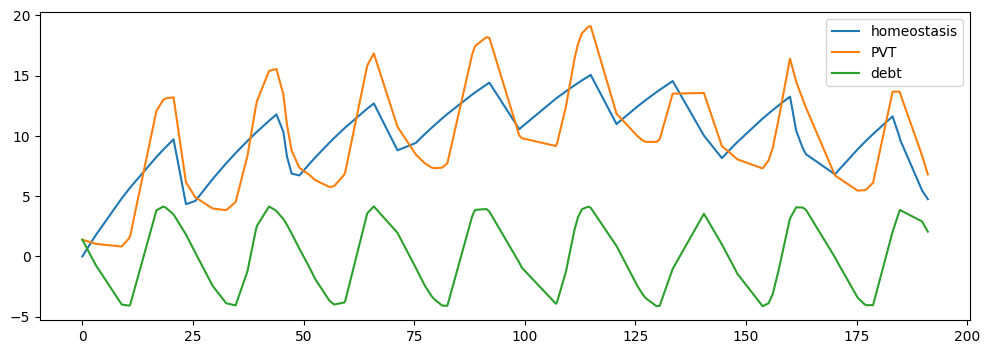

In [7]:
mod
#let's plot the different components of the model to understand better what's going on
plt.figure(figsize=(12, 4))
plt.plot(obs_times, mod["homeostasis"], label="homeostasis")
plt.plot(obs_times, mod["PVT"], label="PVT")
plt.plot(obs_times, mod["PVT"] - mod["homeostasis"], label="debt")

plt.legend()

In [8]:
mod

{'homeostasis': array([ 0.       ,  1.3251419,  1.7845917,  4.8111687,  5.584009 ,
         5.7115498,  8.2469845,  8.84286  ,  9.069628 ,  9.710574 ,
         4.3309097,  4.597492 ,  6.4208755,  7.722273 ,  8.573898 ,
         9.577033 , 10.234297 , 10.335574 , 11.248627 , 11.738524 ,
        11.774648 , 10.322631 ,  8.287901 ,  6.866894 ,  6.714094 ,
         7.5906296,  7.8305454,  8.170796 ,  8.220169 ,  9.423689 ,
         9.812042 , 10.615012 , 10.637963 , 10.687613 , 12.258921 ,
        12.690081 ,  8.7997055,  9.407881 ,  9.929424 , 10.157469 ,
        10.662642 , 10.855344 , 11.439874 , 11.812217 , 13.415818 ,
        13.496955 , 13.609615 , 14.248377 , 14.409896 , 14.412333 ,
        10.547958 , 10.75216  , 13.081596 , 13.161975 , 13.691085 ,
        13.76377  , 13.785527 , 14.186639 , 14.364616 , 14.3853855,
        14.5977545, 14.93354  , 15.019835 , 15.053599 , 10.970216 ,
        11.185289 , 12.343038 , 12.479011 , 12.805717 , 12.957877 ,
        13.636748 , 13.812563 , 1